In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math
from collections import defaultdict
import re
from matplotlib.ticker import PercentFormatter

from annotation_methods.evaluations import evaluate_predictions, retrieve_evaluations_info, perform_efficiency_calculations


In [23]:
# Define per-dataset annotation/removal times (seconds)
ANNOTATION_TIMES = {
    "tomatoes": {
        "add":    {"mean": 4.816719160104988, "se": 0.19224942608703616},
        "remove": {"mean": 2.0005069124423964, "se": 0.09765567385259763},
    },
    "apples": {
        "add":    {"mean": 5.452281021897811, "se": 0.10369701538214723},
        "remove": {"mean": 2.0005069124423964, "se": 0.09765567385259763},
    },
}
AVERAGE_BOXES_PER_IMAGE = {
    "tomatoes": 6.79,     
    "apples": 13.61,    
}
DATASETS = ["tomatoes", "apples"]

# Default removal time (seconds)
DEFAULT_ADD_TIME = 5.15  # seconds
DEFAULT_REMOVE_TIME = 2.00  # seconds   

# Define review time per bounding box (seconds)
REVIEW_TIME_PER_BOX = 1/3  # seconds

# Define hourly compute cost ($/hour)
HOURLY_COMPUTE_COST = 2.03081  # $/hour

# Define IoU thresholds for evaluation
EVAL_IOU_THRESHOLDS = [0.5,0.7,0.9]

# Color scheme (families share a hue, variants differ)
PREFIX_COLORS = {
    "gd_t": "#95eca3",
    "gd_b": "#269f26",
    "mmgd_t": "#E6CCFF",
    "mmgd_b_all": "#9B4DFF",
    "mmgd_l_all": "#2B0057",
    "owlvit_b_16": "#c89881",
    "owlvit_l_14": "#866859",
    "rexomni_transformers": "#03336C",
    "rexomni_vllm": "#16c1d4",
    "yolo11m_inst1000": "#b91c1c", 
    "yolo11m_inst500":  "#d97706",  
    "yolo11m_inst250":  "#fbbf24", 
}

# Human-readable names for legend labels
PREFIX_NAME_MAP = {
    "gd_t": "Grounding DINO-T",
    "gd_b": "Grounding DINO-B",
    "mmgd_t": "MM-Grounding DINO-T",
    "mmgd_b_all": "MM-Grounding DINO-B",
    "mmgd_l_all": "MM-Grounding DINO-L",
    "owlvit_b_16": "OWL-ViT-B/16",
    "owlvit_l_14": "OWL-ViT-L/14",
    "rexomni_transformers": "REX-Omni-Transformers",
    "rexomni_vllm": "REX-Omni-vLLM",
    "yolo11m_inst250": "YOLO11M (250 inst)",
    "yolo11m_inst500": "YOLO11M (500 inst)",
    "yolo11m_inst1000": "YOLO11M (1000 inst)",
}

def prefix_of(name: str) -> str:
    # Strip suffix of the form _r<number>, otherwise keep full name
    if re.search(r"_r\d+$", name):
        return name.rsplit("_", 1)[0]
    return name

In [ ]:
evaluate_predictions(predictions_dir="../Results/test/", iou_thresholds=EVAL_IOU_THRESHOLDS, iou_type="bbox")

## Run evals

In [39]:
evaluate_predictions(predictions_dir="../Results/Experiment_1/", iou_thresholds=EVAL_IOU_THRESHOLDS, iou_type="bbox")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.009
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.006
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.008
 Average Recall     (AR) @[ Io

[{'info': {'timestamp': '2026-01-04 17:10:39',
   'dataset_name': 'apples',
   'subset_name': 'test',
   'model_name': 'gd_b',
   'iou_type': 'bbox',
   'num_initial_bbox': 0,
   'machine_training_time_s': 0.0,
   'inference_time_s': {'total': 7.699665072141215,
    'image_mean': 0.2483762926497166,
    'image_se': 0.0016673524524011727},
   'num_predicted_bbox': {'total': 8,
    'image_mean': 0.25806451612903225,
    'image_se': np.float64(0.10336012766191753)},
   'num_gt_bbox': 412,
   'num_eval_images': 31,
   'num_eval_categories': 2},
  'coco_metrics': {'AP@[.50:.95]': np.float64(0.009323432343234322),
   'AP@0.50': np.float64(0.009900990099009901),
   'AP@0.75': np.float64(0.009900990099009901),
   'AP_small': np.float64(-1.0),
   'AP_medium': np.float64(-1.0),
   'AP_large': np.float64(0.009323432343234322),
   'AR@1': np.float64(0.006199460916442049),
   'AR@10': np.float64(0.007547169811320756),
   'AR@100': np.float64(0.007547169811320756),
   'AR_small': np.float64(-1.0),
 

In [40]:
evaluate_predictions(predictions_dir="../Results/Experiment_2.1/", iou_thresholds=EVAL_IOU_THRESHOLDS, iou_type="bbox")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.009
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.006
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.008
 Average Recall     (AR) @[ Io

[{'info': {'timestamp': '2026-01-04 17:11:12',
   'dataset_name': 'apples',
   'subset_name': 'test',
   'model_name': 'gd_b',
   'iou_type': 'bbox',
   'num_initial_bbox': 0,
   'machine_training_time_s': 0.0,
   'inference_time_s': {'total': 7.699665072141215,
    'image_mean': 0.2483762926497166,
    'image_se': 0.0016673524524011727},
   'num_predicted_bbox': {'total': 8,
    'image_mean': 0.25806451612903225,
    'image_se': np.float64(0.10336012766191753)},
   'num_gt_bbox': 412,
   'num_eval_images': 31,
   'num_eval_categories': 2},
  'coco_metrics': {'AP@[.50:.95]': np.float64(0.009323432343234322),
   'AP@0.50': np.float64(0.009900990099009901),
   'AP@0.75': np.float64(0.009900990099009901),
   'AP_small': np.float64(-1.0),
   'AP_medium': np.float64(-1.0),
   'AP_large': np.float64(0.009323432343234322),
   'AR@1': np.float64(0.006199460916442049),
   'AR@10': np.float64(0.007547169811320756),
   'AR@100': np.float64(0.007547169811320756),
   'AR_small': np.float64(-1.0),
 

## Time efficiency graphs

### With in between runs sem

In [13]:
def plot_t_avg_bbox_vs_size_by_iou(
    dataset: str,
    show_sem: bool = True,
    value: str = "t_avg_bbox",
    eval_iou_thresholds=None,
    eval_root: Path = Path("../Evaluations/"),
    experiment: str = "Experiment_1",
):
    """
    Plot t_avg_bbox vs dataset size for a given dataset, with one subplot per IoU threshold.

    Parameters
    ----------
    dataset : str
        Dataset name prefix, e.g. "apples".
    show_sem : bool, default True
        If True, add between-run standard error bands when multiple runs are available.
    value : str, default "t_avg_bbox"
        Metric key returned by perform_efficiency_calculations.
    eval_iou_thresholds : iterable of float, optional
        IoU thresholds to plot. If None, uses global EVAL_IOU_THRESHOLDS or (0.5, 0.7, 0.9).
    eval_root : Path, default Path("../Evaluations/")
        Root directory containing experiment folders.
    experiment : str, default "Experiment_1"
        Experiment folder name under eval_root.
    """
    exp_dir = eval_root / experiment

    if eval_iou_thresholds is None:
        # Fallback to a default if not provided
        try:
            thresholds = EVAL_IOU_THRESHOLDS
        except NameError:
            thresholds = (0.5, 0.7, 0.9)
    else:
        thresholds = list(eval_iou_thresholds)

    # Range of dataset sizes (x-axis)
    sizes = np.arange(10, 2001, 10)

    # Figure with one subplot per IoU threshold
    n_iou = len(thresholds)
    fig_width = 4 * n_iou

    fig, axes = plt.subplots(
        1,
        n_iou,
        figsize=(fig_width, 5),
        sharey=True,
        constrained_layout=True,
    )
    if n_iou == 1:
        axes = [axes]

    all_handles = []
    all_labels = []

    for col_idx, quality_threshold in enumerate(thresholds):
        ax = axes[col_idx]

        curves_by_prefix = defaultdict(list)
        manual_benchmark = None

        # ----------------------------------------------------------
        # Collect curves grouped by prefix for this IoU threshold
        # ----------------------------------------------------------
        for json_path in sorted(exp_dir.glob(f"{dataset}*.json")):
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            eval_info = retrieve_evaluations_info(
                quality_threshold=quality_threshold, data=data
            )
            model_name = eval_info["model_name"]
            prefix = prefix_of(model_name)

            # print(f"[{dataset} / IoU {quality_threshold}] Processing: {model_name}")

            if manual_benchmark is None:
                manual_benchmark = eval_info["t_add"]

            calc_kwargs = {k: v for k, v in eval_info.items() if k != "model_name"}

            t_avg_values = []
            for s in sizes:
                res = perform_efficiency_calculations(s, **calc_kwargs)
                t_avg_values.append(res[value])

            curves_by_prefix[prefix].append(np.array(t_avg_values))

        # ----------------------------------------------------------
        # Average repeats per prefix and plot (with optional SEM)
        # ----------------------------------------------------------
        for prefix, curves in curves_by_prefix.items():
            curves_arr = np.vstack(curves)
            mean_curve = curves_arr.mean(axis=0)

            n_runs = curves_arr.shape[0]
            sem_curve = None
            if show_sem and n_runs > 1:
                sem_curve = curves_arr.std(axis=0, ddof=1) / np.sqrt(n_runs)

            color = PREFIX_COLORS.get(prefix, "black")
            base_label = PREFIX_NAME_MAP.get(prefix, prefix)
            if show_sem:
                label = f"{base_label} ({n_runs} run{'s' if n_runs > 1 else ''})"
            else:
                label = f"{base_label}"

            line, = ax.plot(
                sizes,
                mean_curve,
                label=label,
                color=color,
            )

            if sem_curve is not None:
                ax.fill_between(
                    sizes,
                    mean_curve - sem_curve,
                    mean_curve + sem_curve,
                    color=color,
                    alpha=0.15,
                    linewidth=1,
                )

            all_handles.append(line)
            all_labels.append(label)

        # Manual benchmark reference line
        if manual_benchmark is not None:
            mb_line = ax.axhline(
                manual_benchmark,
                linestyle="--",
                color="black",
                label="manual benchmark",
            )
            all_handles.append(mb_line)
            all_labels.append("manual benchmark")

        ax.set_xlabel("Dataset Size (images)")
        if col_idx == 0:
            ax.set_ylabel("Average Annotation Time per Bounding Box (s)")

        ax.set_title(
            f"{dataset.capitalize()} @ IoU {quality_threshold}",
            fontsize=10,
        )
        ax.set_xlim(0, sizes[-1])
        ax.grid(True, linewidth=0.5, alpha=0.3)


    # ----------------------------------------------------------
    # Single legend on the right (deduplicated)
    # ----------------------------------------------------------
    by_label = {}
    for h, lab in zip(all_handles, all_labels):
        by_label[lab] = h

    leg = fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        borderaxespad=0.0,
        title="Evaluated Models",
        handlelength=2.5,
        labelspacing=0.6,
    )
    leg.get_title().set_fontweight("bold")

    fig.suptitle(
        f"Average bbox Annotation Time vs Dataset Size ({dataset.capitalize()})",
        y=1.05,
    )

    plt.show()


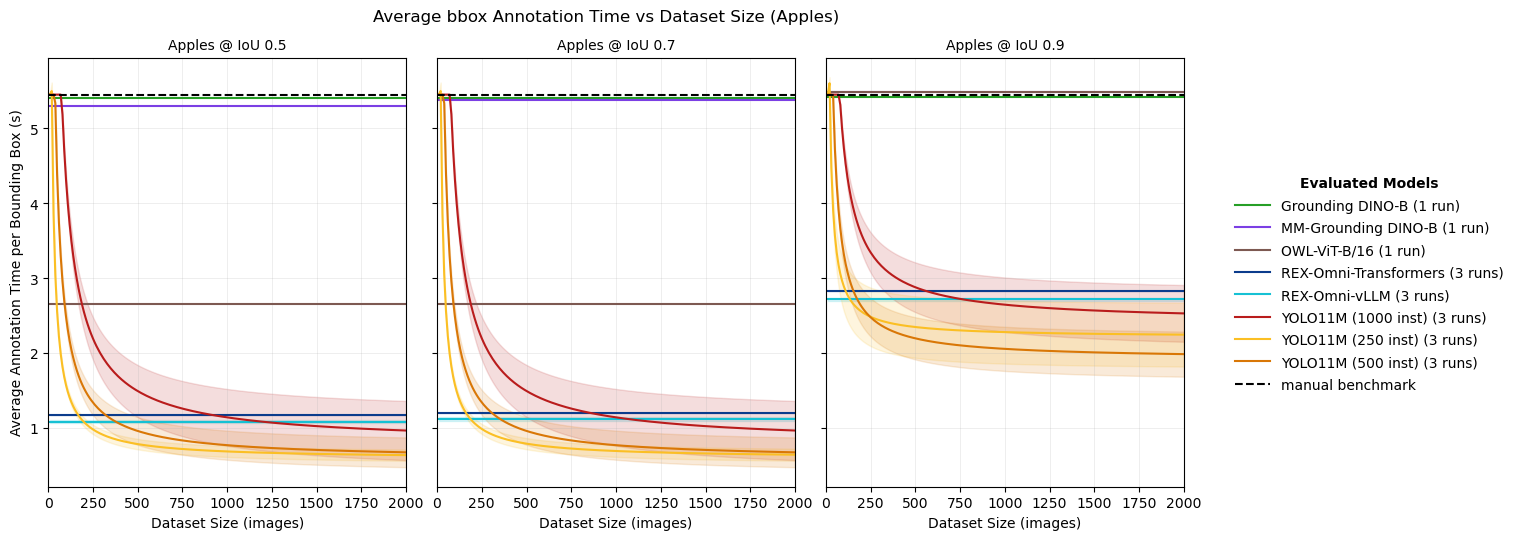

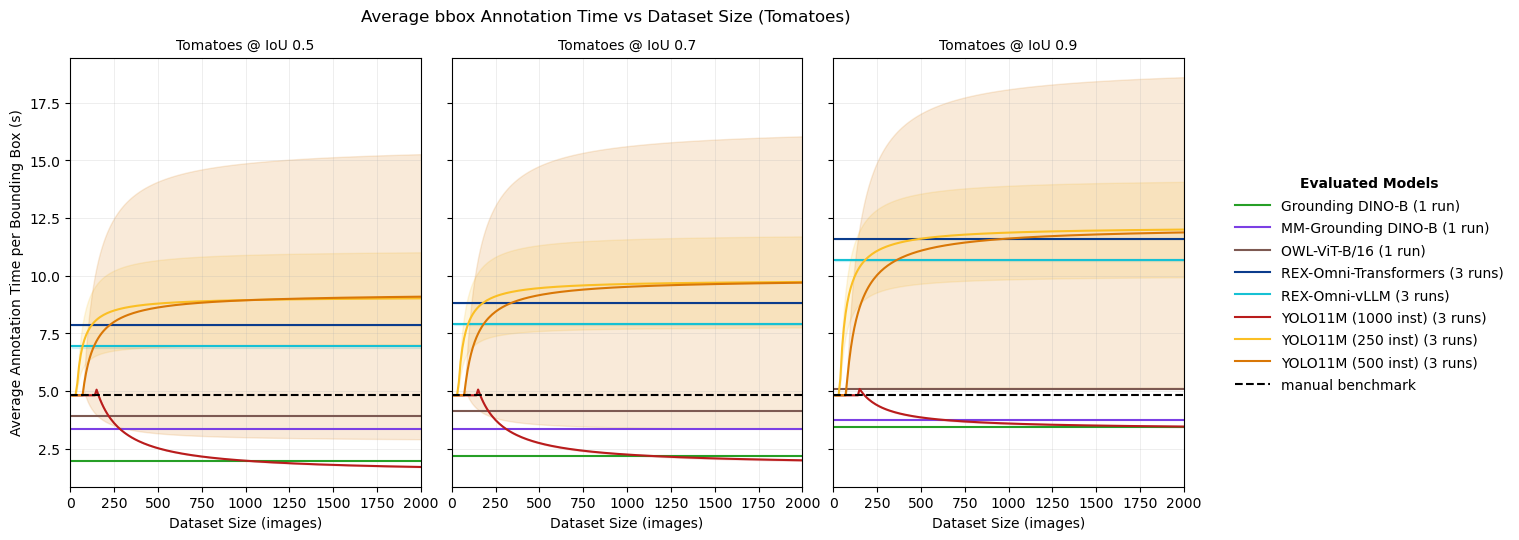

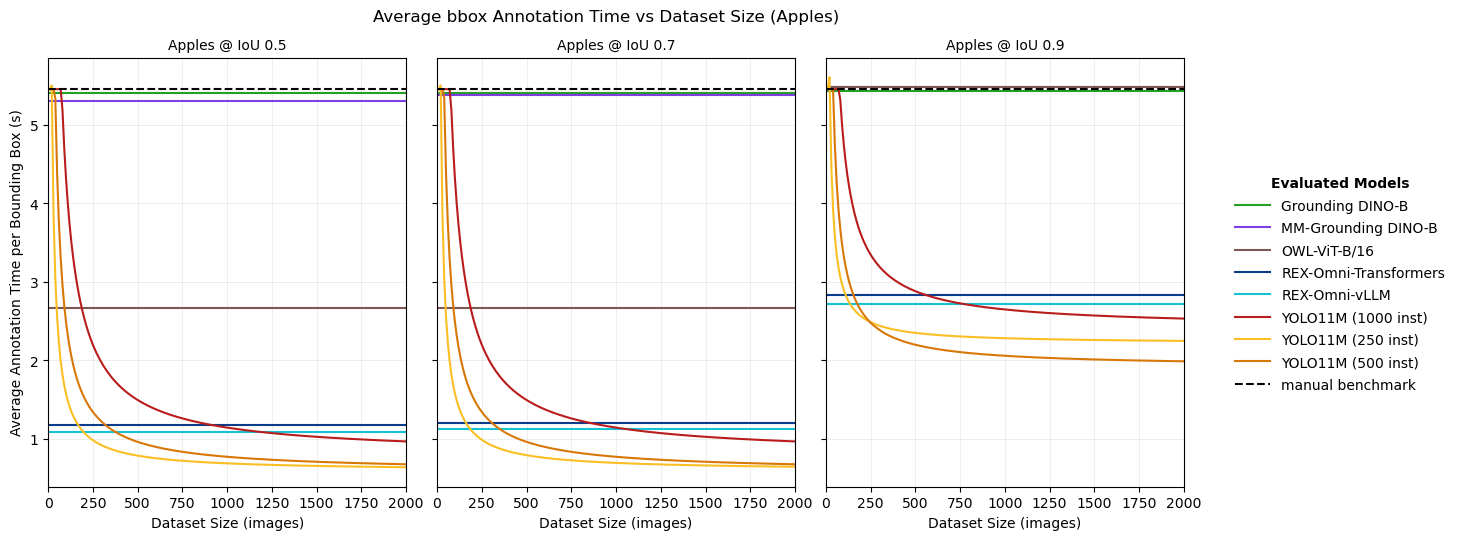

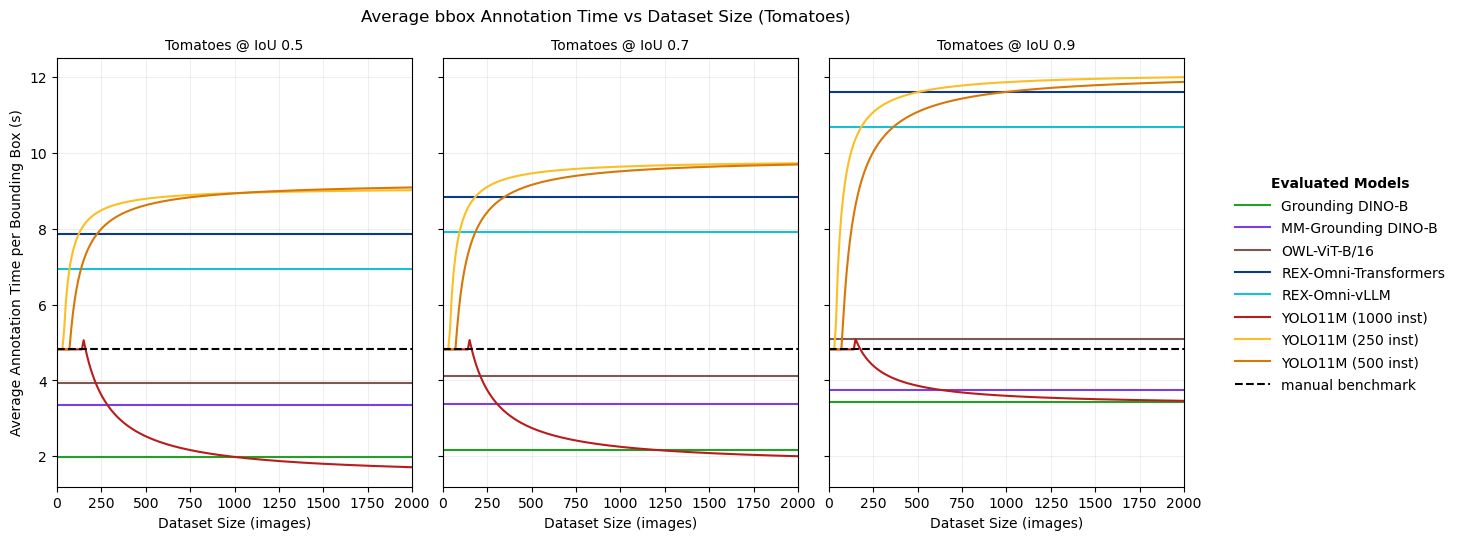

In [14]:
# With SEM bands
plot_t_avg_bbox_vs_size_by_iou(dataset="apples", show_sem=True)
plot_t_avg_bbox_vs_size_by_iou(dataset="tomatoes", show_sem=True)

# Without SEM bands
plot_t_avg_bbox_vs_size_by_iou(dataset="apples", show_sem=False)
plot_t_avg_bbox_vs_size_by_iou(dataset="tomatoes", show_sem=False)



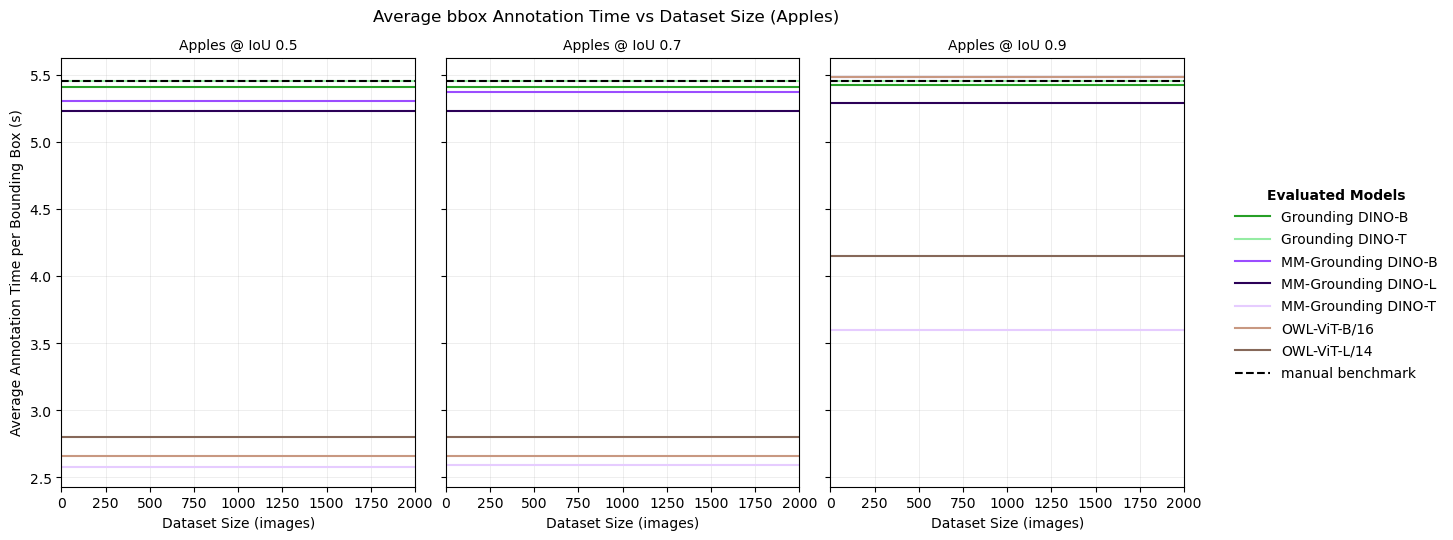

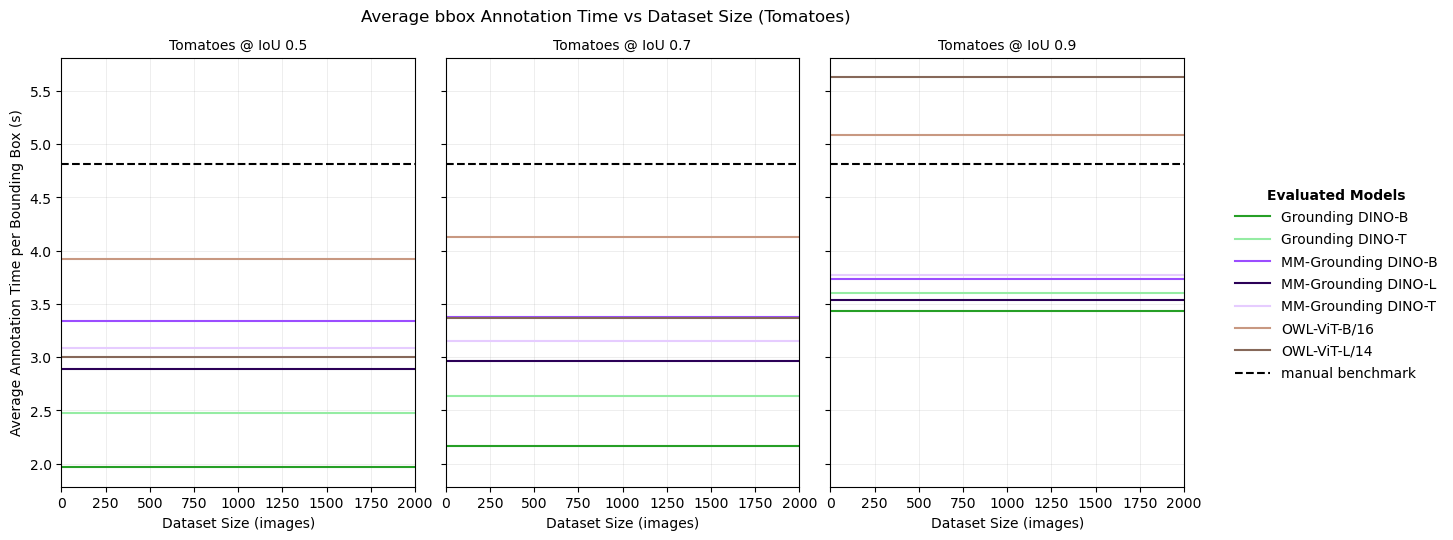

In [24]:
plot_t_avg_bbox_vs_size_by_iou(dataset="apples",experiment= 'Experiment_2.1', show_sem=False)
plot_t_avg_bbox_vs_size_by_iou(dataset="tomatoes",experiment= 'Experiment_2.1', show_sem=False)

### Within runs measurement error

In [16]:
def perform_efficiency_calculations_with_uncertainty(
    dataset_size_images,
    *,
    num_initial_bbox,
    t_add,
    t_remove,
    t_review,
    t_train,
    image_t_inf,
    image_num_pred,
    precision,
    recall,
    dataset,
    se_t_add,
    se_t_remove,
    se_image_t_inf,
    se_image_num_pred,
    n_samples=1000,
    random_state=None,
    **_,
):
    """
    Returns mean and propagated SE for each output quantity
    using Monte-Carlo error propagation.
    """
    rng = np.random.default_rng(random_state)

    # Draw samples for the uncertain inputs (assume normal, independent)
    t_add_samples = rng.normal(t_add, se_t_add, size=n_samples)
    t_remove_samples = rng.normal(t_remove, se_t_remove, size=n_samples)
    image_t_inf_samples = rng.normal(image_t_inf, se_image_t_inf, size=n_samples)
    image_num_pred_samples = rng.normal(image_num_pred, se_image_num_pred, size=n_samples)

    # Optional: enforce non-negativity for time-like quantities
    t_add_samples = np.clip(t_add_samples, 0, None)
    t_remove_samples = np.clip(t_remove_samples, 0, None)
    image_t_inf_samples = np.clip(image_t_inf_samples, 0, None)
    image_num_pred_samples = np.clip(image_num_pred_samples, 0, None)

    # Collect all sample outputs
    sample_results = []

    for i in range(n_samples):
        res_i = perform_efficiency_calculations(
            dataset_size_images,
            num_initial_bbox=num_initial_bbox,
            t_add=float(t_add_samples[i]),
            t_remove=float(t_remove_samples[i]),
            t_review=t_review,
            t_train=t_train,
            image_t_inf=float(image_t_inf_samples[i]),
            image_num_pred=float(image_num_pred_samples[i]),
            precision=precision,
            recall=recall,
            dataset=dataset,
        )
        sample_results.append(res_i)

    # Convert list-of-dicts to dict-of-arrays
    keys = sample_results[0].keys()
    arrays = {k: np.array([r[k] for r in sample_results], dtype=float) for k in keys if k != "dataset"}

    # Compute mean and SE across samples
    mean_res = {k: float(v.mean()) for k, v in arrays.items()}
    se_res = {f"{k}_se": float(v.std(ddof=1)) for k, v in arrays.items()}

    # Keep dataset label
    mean_res["dataset"] = dataset

    # Merge means and SEs into a single dict
    mean_res.update(se_res)
    return mean_res


[VLMs / tomatoes] Processing model: gd_b  (prefix: gd_b)
[VLMs / tomatoes] Processing model: gd_t  (prefix: gd_t)
[VLMs / tomatoes] Processing model: mmgd_b_all  (prefix: mmgd_b_all)
[VLMs / tomatoes] Processing model: mmgd_l_all  (prefix: mmgd_l_all)
[VLMs / tomatoes] Processing model: mmgd_t  (prefix: mmgd_t)
[VLMs / tomatoes] Processing model: owlvit_b_16  (prefix: owlvit_b_16)
[VLMs / tomatoes] Processing model: owlvit_l_14  (prefix: owlvit_l_14)
[VLMs / apples] Processing model: gd_b  (prefix: gd_b)
[VLMs / apples] Processing model: gd_t  (prefix: gd_t)
[VLMs / apples] Processing model: mmgd_b_all  (prefix: mmgd_b_all)
[VLMs / apples] Processing model: mmgd_l_all  (prefix: mmgd_l_all)
[VLMs / apples] Processing model: mmgd_t  (prefix: mmgd_t)
[VLMs / apples] Processing model: owlvit_b_16  (prefix: owlvit_b_16)
[VLMs / apples] Processing model: owlvit_l_14  (prefix: owlvit_l_14)


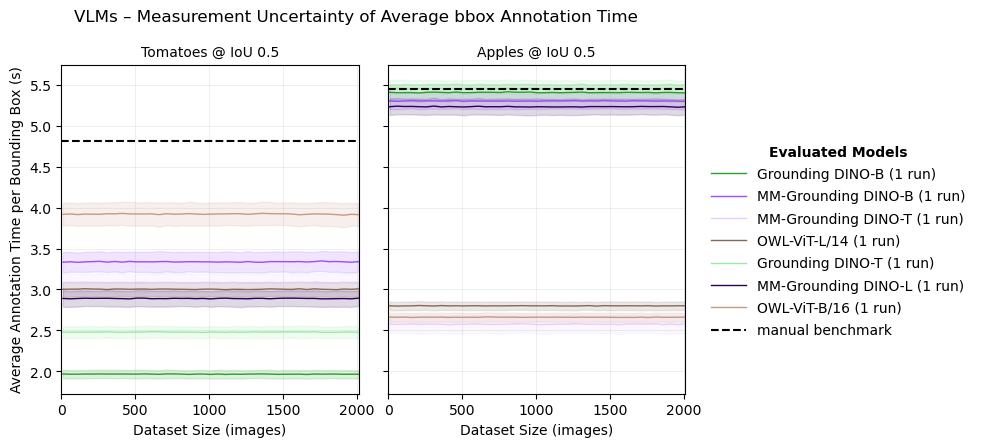

[MLLMs / tomatoes] Processing model: rexomni_transformers_r0  (prefix: rexomni_transformers)
[MLLMs / tomatoes] Processing model: rexomni_transformers_r1  (prefix: rexomni_transformers)
[MLLMs / tomatoes] Processing model: rexomni_transformers_r2  (prefix: rexomni_transformers)
[MLLMs / tomatoes] Processing model: rexomni_vllm_r0  (prefix: rexomni_vllm)
[MLLMs / tomatoes] Processing model: rexomni_vllm_r1  (prefix: rexomni_vllm)
[MLLMs / tomatoes] Processing model: rexomni_vllm_r2  (prefix: rexomni_vllm)
[MLLMs / apples] Processing model: rexomni_transformers_r0  (prefix: rexomni_transformers)
[MLLMs / apples] Processing model: rexomni_transformers_r1  (prefix: rexomni_transformers)
[MLLMs / apples] Processing model: rexomni_transformers_r2  (prefix: rexomni_transformers)
[MLLMs / apples] Processing model: rexomni_vllm_r0  (prefix: rexomni_vllm)
[MLLMs / apples] Processing model: rexomni_vllm_r1  (prefix: rexomni_vllm)
[MLLMs / apples] Processing model: rexomni_vllm_r2  (prefix: rexomn

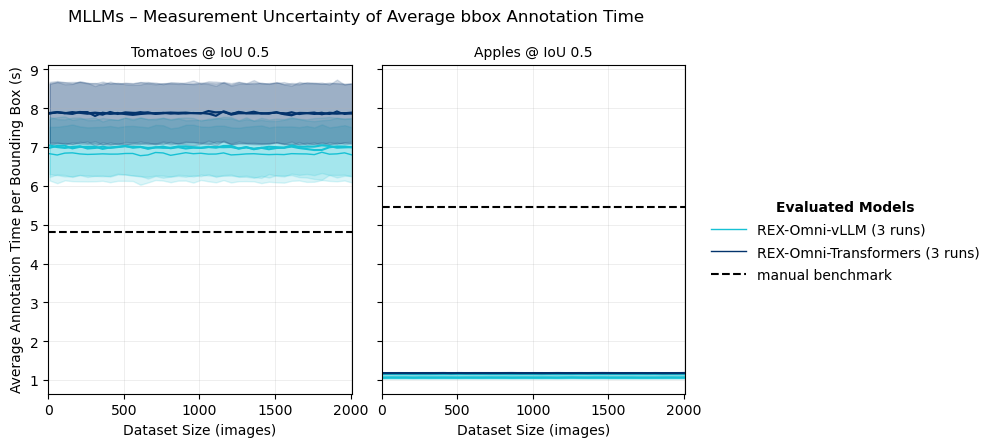

[YOLO / tomatoes] Processing model: yolo11m_inst1000_r0  (prefix: yolo11m_inst1000)
[YOLO / tomatoes] Processing model: yolo11m_inst1000_r1  (prefix: yolo11m_inst1000)
[YOLO / tomatoes] Processing model: yolo11m_inst1000_r2  (prefix: yolo11m_inst1000)
[YOLO / tomatoes] Processing model: yolo11m_inst250_r0  (prefix: yolo11m_inst250)
[YOLO / tomatoes] Processing model: yolo11m_inst250_r1  (prefix: yolo11m_inst250)
[YOLO / tomatoes] Processing model: yolo11m_inst250_r2  (prefix: yolo11m_inst250)
[YOLO / tomatoes] Processing model: yolo11m_inst500_r0  (prefix: yolo11m_inst500)
[YOLO / tomatoes] Processing model: yolo11m_inst500_r1  (prefix: yolo11m_inst500)
[YOLO / tomatoes] Processing model: yolo11m_inst500_r2  (prefix: yolo11m_inst500)
[YOLO / apples] Processing model: yolo11m_inst1000_r0  (prefix: yolo11m_inst1000)
[YOLO / apples] Processing model: yolo11m_inst1000_r1  (prefix: yolo11m_inst1000)
[YOLO / apples] Processing model: yolo11m_inst1000_r2  (prefix: yolo11m_inst1000)
[YOLO / ap

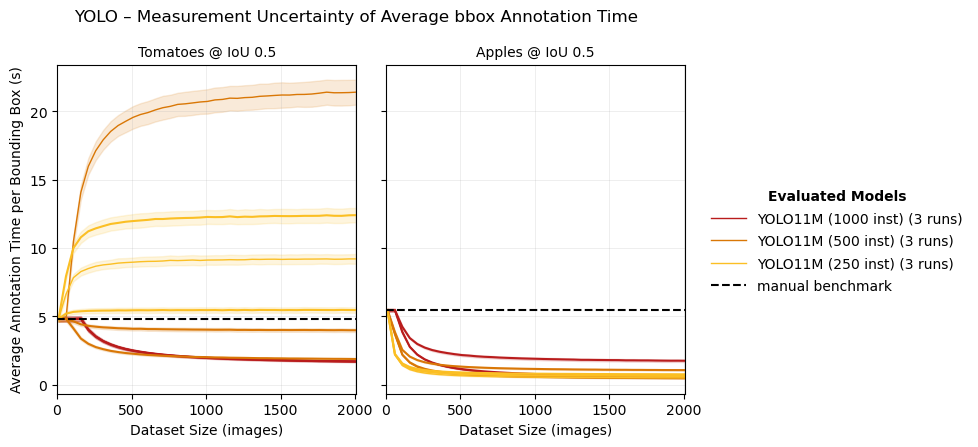

In [25]:
# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
EVAL_ROOT = Path("../Evaluations/")
experiment = "Experiment_1"
exp_dir = EVAL_ROOT / experiment
quality_threshold = 0.5
value = "t_avg_bbox"

# Range of dataset sizes (x-axis)
sizes = np.arange(10, 2011, 50)

# Model families
groups = {
    "VLMs": {
        "gd_t", "gd_b",
        "mmgd_t", "mmgd_b_all", "mmgd_l_all",
        "owlvit_b_16", "owlvit_l_14",
    },
    "MLLMs": {"rexomni_transformers", "rexomni_vllm"},
    "YOLO": {"yolo11m_inst250", "yolo11m_inst500", "yolo11m_inst1000"},
}

# ----------------------------------------------------------------------
# Loop over model families and create one figure per family
# ----------------------------------------------------------------------
for group_name, group_prefixes in groups.items():
    # Select experiment per family
    if group_name == "VLMs":
        experiment = "Experiment_2.1"
    else:
        experiment = "Experiment_1"

    exp_dir = EVAL_ROOT / experiment

    n_datasets = len(DATASETS)

    # Width scales with number of datasets (slightly smaller than before)
    fig_width = 3.5 * n_datasets

    # IMPORTANT: use constrained_layout to let mpl handle spacing
    fig, axes = plt.subplots(
        1,
        n_datasets,
        figsize=(fig_width, 4),
        sharey=True,
        constrained_layout=True,   # <-- key change
    )
    if n_datasets == 1:
        axes = [axes]

    all_handles = []
    all_labels = []
    manual_benchmark_first = None

    for col_idx, dataset in enumerate(DATASETS):
        ax = axes[col_idx]

        # ------------------------------------------------------------------
        # Collect curves_by_prefix for this dataset (no averaging over runs)
        # ------------------------------------------------------------------
        curves_by_prefix = defaultdict(list)
        manual_benchmark = None

        for json_path in sorted(exp_dir.glob(f"{dataset}*.json")):
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            eval_info = retrieve_evaluations_info(
                quality_threshold=quality_threshold, data=data
            )
            model_name = eval_info["model_name"]
            prefix = prefix_of(model_name)

            # Only keep models that belong to this group
            if prefix not in group_prefixes:
                continue

            print(
                f"[{group_name} / {dataset}] "
                f"Processing model: {model_name}  (prefix: {prefix})"
            )

            if manual_benchmark is None:
                manual_benchmark = eval_info["t_add"]
                if manual_benchmark_first is None:
                    manual_benchmark_first = manual_benchmark

            # Base kwargs for the non-uncertain parameters
            calc_kwargs = {
                k: v
                for k, v in eval_info.items()
                if k
                not in (
                    "model_name",
                    "se_t_add",
                    "se_t_remove",
                    "se_image_t_inf",
                    "se_image_num_pred",
                )
            }

            se_t_add = eval_info["se_t_add"]
            se_t_remove = eval_info["se_t_remove"]
            se_image_t_inf = eval_info["se_image_t_inf"]
            se_image_num_pred = eval_info["se_image_num_pred"]

            t_avg_values = []
            t_avg_se_values = []

            for s in sizes:
                res = perform_efficiency_calculations_with_uncertainty(
                    s,
                    **calc_kwargs,
                    se_t_add=se_t_add,
                    se_t_remove=se_t_remove,
                    se_image_t_inf=se_image_t_inf,
                    se_image_num_pred=se_image_num_pred,
                    n_samples=1000,
                )
                t_avg_values.append(res[value])
                t_avg_se_values.append(res[f"{value}_se"])

            curves_by_prefix[prefix].append(
                {
                    "mean": np.array(t_avg_values),
                    "se": np.array(t_avg_se_values),
                }
            )

        # ------------------------------------------------------------------
        # Plot for this dataset on its axis
        # ------------------------------------------------------------------
        any_plotted = False

        for prefix in group_prefixes:
            runs = curves_by_prefix.get(prefix)
            if not runs:
                continue

            color = PREFIX_COLORS.get(prefix, "black")
            base_label = PREFIX_NAME_MAP.get(prefix, prefix)
            n_runs = len(runs)

            for i, run in enumerate(runs):
                mean_curve = run["mean"]
                se_curve = run["se"]

                # Only first run gets a legend entry: "Model (n runs)"
                if i == 0:
                    run_suffix = "run" if n_runs == 1 else "runs"
                    label = f"{base_label} ({n_runs} {run_suffix})"
                    line, = ax.plot(
                        sizes,
                        mean_curve,
                        label=label,
                        color=color,
                        linewidth=1
                    )
                    all_handles.append(line)
                    all_labels.append(label)
                else:
                    ax.plot(
                        sizes,
                        mean_curve,
                        color=color,
                    )

                # SE band (no legend entry)
                ax.fill_between(
                    sizes,
                    mean_curve - se_curve,
                    mean_curve + se_curve,
                    color=color,
                    alpha=0.15,
                    linewidth=1,
                )

                any_plotted = True

        if not any_plotted:
            ax.set_visible(False)
            continue

        # Manual benchmark reference line; only first dataset contributes to legend
        if manual_benchmark is not None:
            if col_idx == 0:
                mb_line = ax.axhline(
                    manual_benchmark,
                    linestyle="--",
                    color="black",
                    label="manual benchmark",
                )
                all_handles.append(mb_line)
                all_labels.append("manual benchmark")
            else:
                ax.axhline(
                    manual_benchmark,
                    linestyle="--",
                    color="black",
                )

        ax.set_xlabel("Dataset Size (images)")
        if col_idx == 0:
            ax.set_ylabel("Average Annotation Time per Bounding Box (s)")

        ax.set_title(
            f"{dataset[:1].upper() + dataset[1:]}" f" @ IoU {quality_threshold}",
            fontsize=10,   # smaller title font
        )
        ax.set_xlim(0, sizes[-1])
        ax.grid(True, linewidth=0.5, alpha=0.3)


    # ------------------------------------------------------------------
    # Single legend on the right
    # ------------------------------------------------------------------
    by_label = {}
    for h, lab in zip(all_handles, all_labels):
        by_label[lab] = h

    leg = fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        borderaxespad=0.0,
        title="Evaluated Models",
        handlelength=2.5,
        labelspacing=0.6,
    )
    # Match font weight with your other figures
    leg.get_title().set_fontweight("bold")


    fig.suptitle(
        f"{group_name} – Measurement Uncertainty of Average bbox Annotation Time",
        y=1.08,
    )

    # REMOVE the manual tight_layout with rect
    # fig.tight_layout(rect=(0, 0, 0.78, 1))

    plt.show()

## manual workload 

In [30]:
def plot_manual_workload_reduction_vs_size(
    dataset="tomatoes",
    value="pct_manual_workload_red",
    eval_iou_thresholds=(0.5, 0.7, 0.9),
    show_variability=True,                  # <--- toggle SE bands on/off
    eval_root=Path("../Evaluations/"),
    experiment="Experiment_1",
):
    exp_dir = eval_root / experiment

    # Range of dataset sizes (x-axis)
    sizes = np.arange(10, 2001, 10)

    # Figure with one subplot per IoU threshold
    n_iou = len(eval_iou_thresholds)
    fig_width = 4 * n_iou  # width scales with number of subplots

    fig, axes = plt.subplots(
        1,
        n_iou,
        figsize=(fig_width, 6),
        sharey=True,
        constrained_layout=True,
    )
    if n_iou == 1:
        axes = [axes]

    all_handles = []
    all_labels = []

    for col_idx, quality_threshold in enumerate(eval_iou_thresholds):
        ax = axes[col_idx]

        # --------------------------------------------------------------
        # Collect curves grouped by prefix for this IoU threshold
        # --------------------------------------------------------------
        curves_by_prefix = defaultdict(list)
        manual_benchmark = None

        for json_path in sorted(exp_dir.glob(f"{dataset}*.json")):
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            eval_info = retrieve_evaluations_info(
                quality_threshold=quality_threshold, data=data
            )
            model_name = eval_info["model_name"]
            prefix = prefix_of(model_name)

            # print(
            #     f"[IoU {quality_threshold}] "
            #     f"Processing model: {model_name}  (prefix: {prefix})"
            # )

            if manual_benchmark is None:
                # For workload reduction we keep this at 0 as in your original script
                manual_benchmark = 0

            calc_kwargs = {k: v for k, v in eval_info.items() if k not in ("model_name",)}

            t_avg_values = []
            for s in sizes:
                res = perform_efficiency_calculations(s, **calc_kwargs)
                t_avg_values.append(res[value])

            curves_by_prefix[prefix].append(np.array(t_avg_values))

        # --------------------------------------------------------------
        # Average repeats per prefix and plot on this axis
        # --------------------------------------------------------------
        any_plotted = False

        for prefix, curves in curves_by_prefix.items():
            curves = np.array(curves)               # shape: (n_runs, n_sizes)
            n_runs = curves.shape[0]

            mean_curve = curves.mean(axis=0)
            se_curve = None
            if show_variability and n_runs > 1:
                # between-run standard error at each dataset size
                se_curve = curves.std(axis=0, ddof=1) / np.sqrt(n_runs)

            color = PREFIX_COLORS.get(prefix, "black")
            base_label = PREFIX_NAME_MAP.get(prefix, prefix)
            if show_variability:
                label = f"{base_label} ({n_runs} run{'s' if n_runs > 1 else ''})"
            else:
                label = base_label

            line, = ax.plot(
                sizes,
                mean_curve,
                label=label,
                color=color,
            )

            # Add variability band only if we want it and actually have >1 run
            if se_curve is not None:
                ax.fill_between(
                    sizes,
                    mean_curve - se_curve,
                    mean_curve + se_curve,
                    color=color,
                    alpha=0.15,
                    linewidth=1,
                )

            # Store handles and labels (we will deduplicate for the figure legend)
            all_handles.append(line)
            all_labels.append(line.get_label())
            any_plotted = True

        # Manual benchmark reference line
        if manual_benchmark is not None and any_plotted:
            mb_line = ax.axhline(
                manual_benchmark,
                linestyle="--",
                color="black",
                label="manual benchmark",
            )
            all_handles.append(mb_line)
            all_labels.append(mb_line.get_label())

        ax.set_xlabel("Dataset Size (images)")
        if col_idx == 0:
            ax.set_ylabel("Average Manual Workload Reduction (pp.)")

        ax.set_title(
            f"{dataset[:1].upper() + dataset[1:]} @ IoU {quality_threshold}",
            fontsize=10,  # slightly smaller title
        )
        ax.set_xlim(0, sizes[-1])
        ax.grid(True, linewidth=0.5, alpha=0.3)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(25))  # ticks every 25

    # --------------------------------------------------------------
    # Single legend on the right (deduplicated)
    # --------------------------------------------------------------
    by_label = {}
    for h, lab in zip(all_handles, all_labels):
        by_label[lab] = h  # last handle wins, but all are equivalent visually

    leg = fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        borderaxespad=0.0,
        title="Evaluated Models",
        handlelength=2.5,
        labelspacing=0.6,
    )
    leg.get_title().set_fontweight("bold")

    fig.suptitle(
        f"Average Manual Workload Reduction vs Dataset Size ({dataset[:1].upper() + dataset[1:]})",
        y=1.05,
    )

    plt.show()


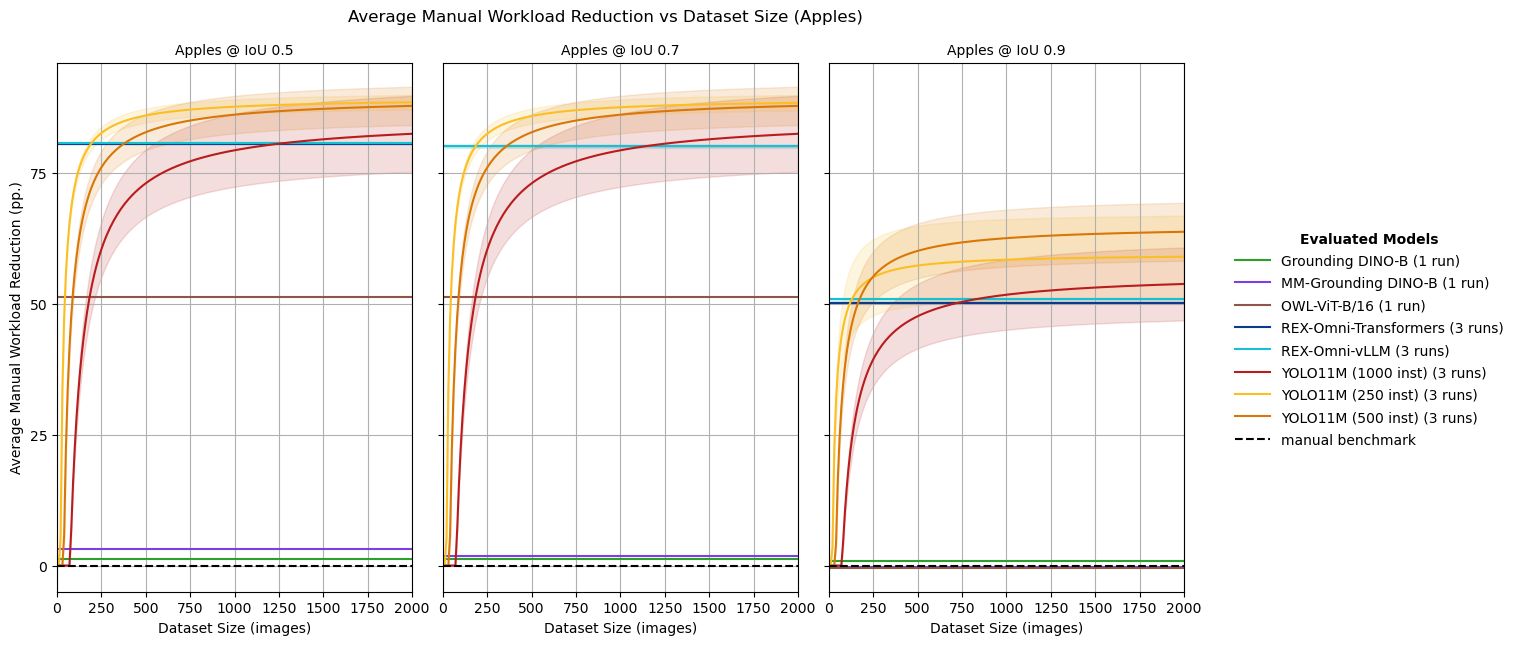

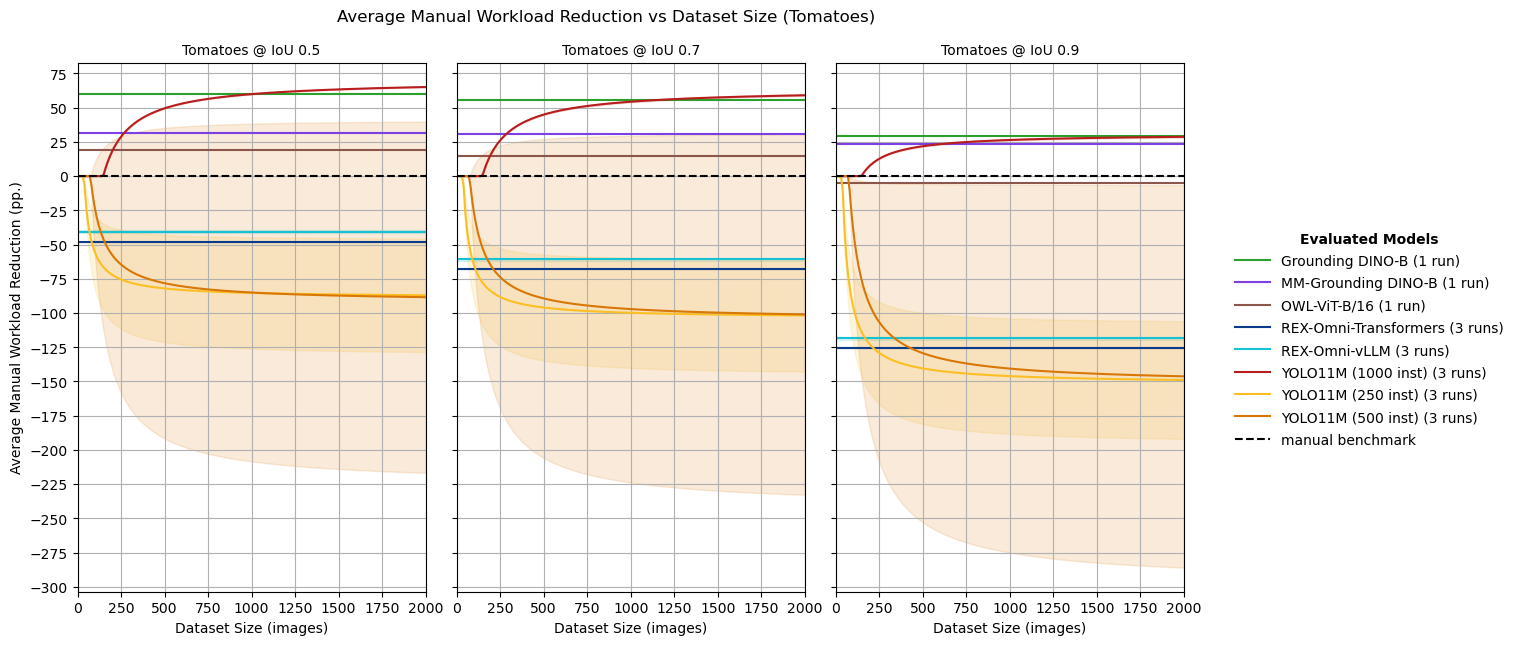

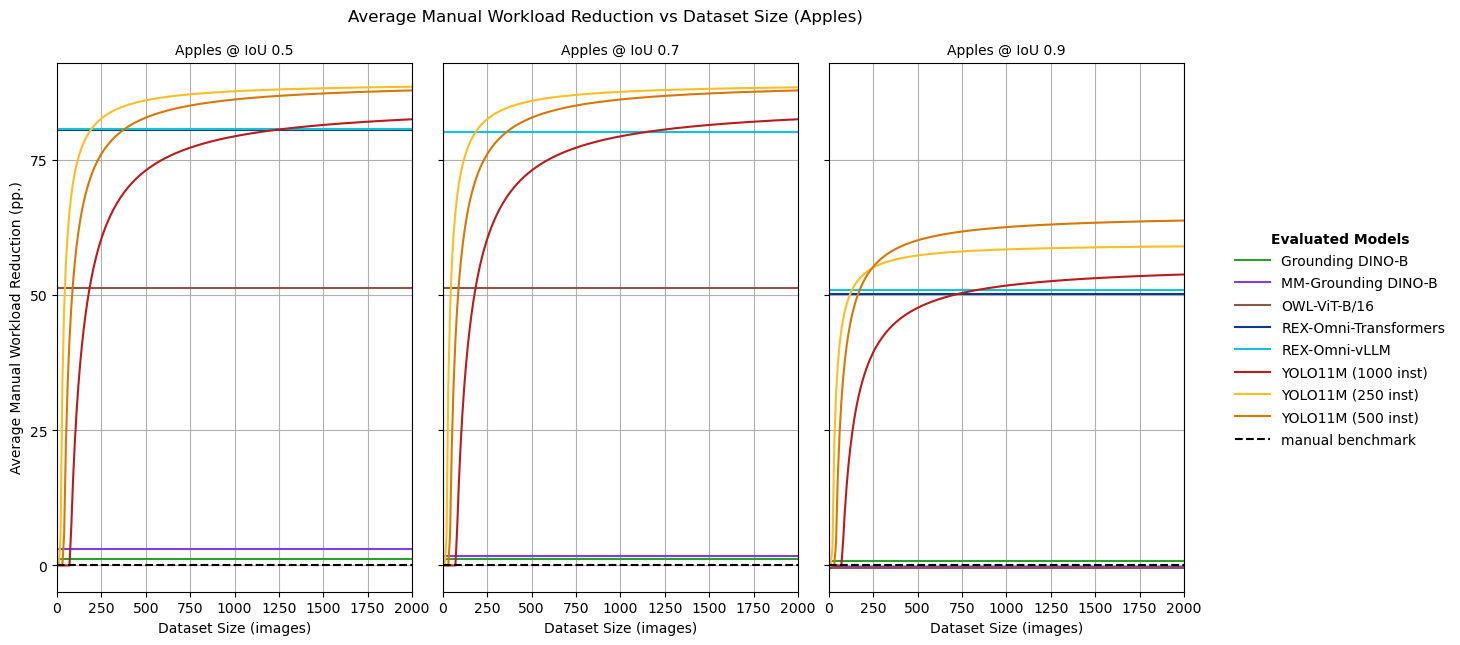

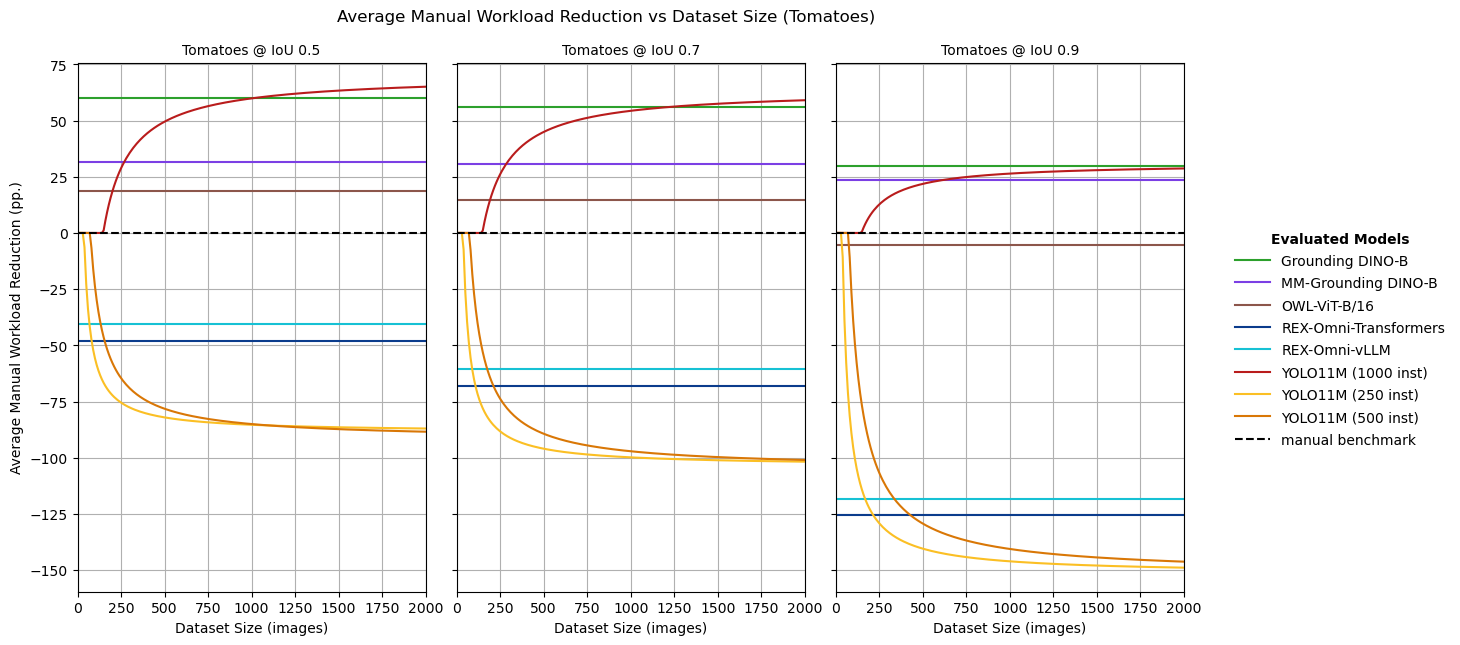

In [131]:
# With variability bands
plot_manual_workload_reduction_vs_size(dataset='apples' ,show_variability=True)
plot_manual_workload_reduction_vs_size(dataset='tomatoes' ,show_variability=True)

# Without variability bands
plot_manual_workload_reduction_vs_size(dataset='apples' ,show_variability=False)
plot_manual_workload_reduction_vs_size(dataset='tomatoes' ,show_variability=False)

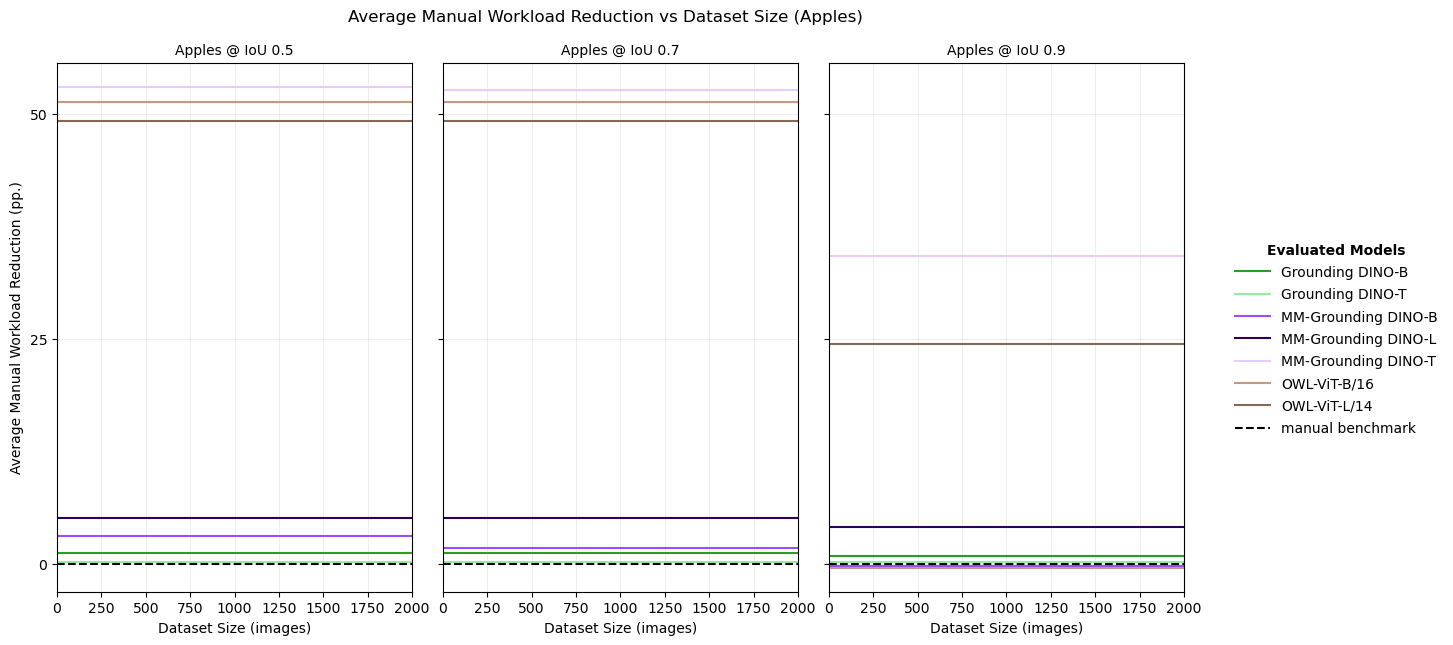

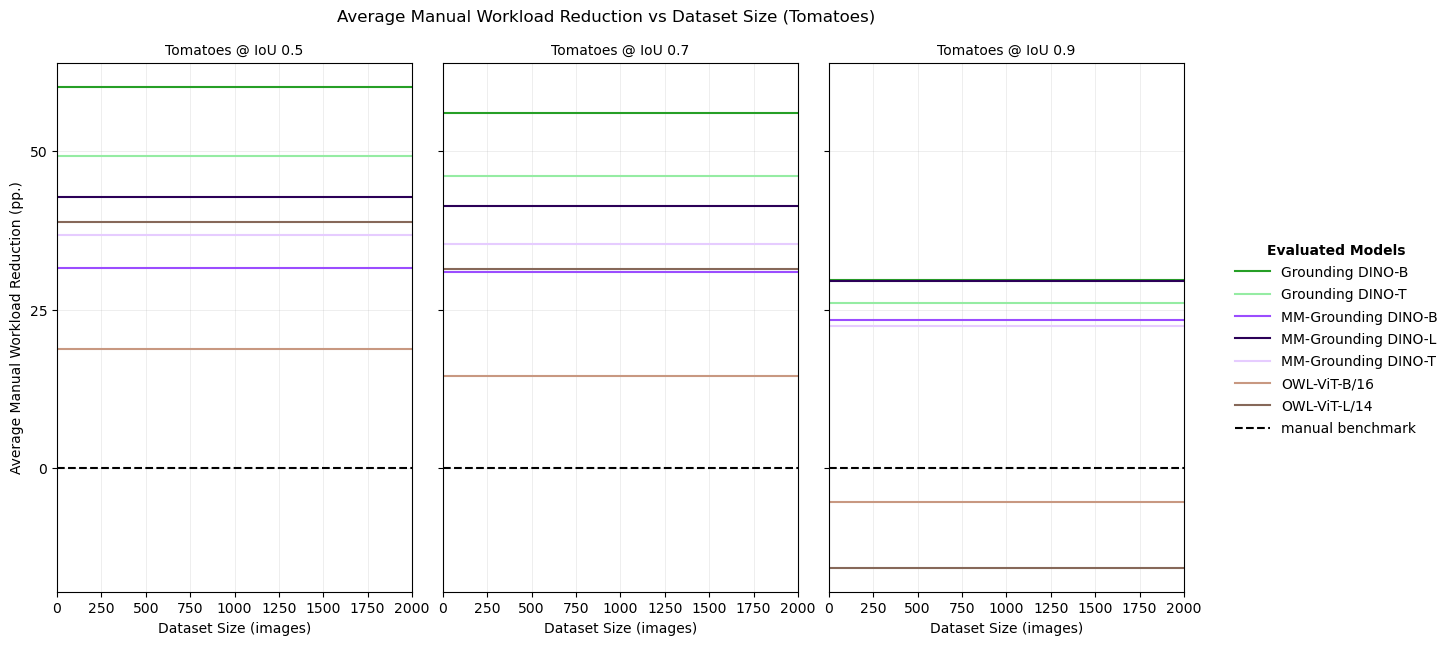

In [31]:
plot_manual_workload_reduction_vs_size(dataset='apples' ,experiment= "Experiment_2.1",show_variability=False)
plot_manual_workload_reduction_vs_size(dataset='tomatoes',experiment= "Experiment_2.1" ,show_variability=False)

## Cost

In [26]:
def plot_total_compute_cost(
    DATASETS,
    eval_root=Path("../Evaluations/"),
    experiment="Experiment_1",
    quality_threshold=0.5,
    value="c_total",
    size_start=10,
    size_stop=2001,
    size_step=10,
):
    """
    Plot total estimated compute cost vs dataset size for all models found
    in the given experiment JSON files, grouped by dataset name.

    Parameters
    ----------
    DATASETS : list[str]
        Dataset name prefixes used to match JSON files (e.g. 'coco', 'openimages', ...).
    eval_root : Path
        Root directory containing experiment subdirectories.
    experiment : str
        Name of the experiment subdirectory within eval_root.
    quality_threshold : float
        IoU quality threshold passed to retrieve_evaluations_info.
    value : str
        Key in `perform_efficiency_calculations` result to plot (default: 'c_total').
    size_start, size_stop, size_step : int
        Range arguments for np.arange to define dataset sizes (x-axis).
    """
    exp_dir = eval_root / experiment
    sizes = np.arange(size_start, size_stop, size_step)

    # ----------------------------------------------------------------------
    # Figure with one subplot per dataset
    # ----------------------------------------------------------------------
    n_datasets = len(DATASETS)
    fig_width = 4 * n_datasets  # width scales with number of subplots

    fig, axes = plt.subplots(
        1,
        n_datasets,
        figsize=(fig_width, 5),
        sharey=True,
        constrained_layout=True,
    )
    if n_datasets == 1:
        axes = [axes]

    all_handles = []
    all_labels = []

    for col_idx, dataset in enumerate(DATASETS):
        ax = axes[col_idx]

        # --------------------------------------------------------------
        # Collect curves grouped by prefix for this dataset
        # --------------------------------------------------------------
        curves_by_prefix = defaultdict(list)

        for json_path in sorted(exp_dir.glob(f"{dataset}*.json")):
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            eval_info = retrieve_evaluations_info(
                quality_threshold=quality_threshold, data=data
            )
            model_name = eval_info["model_name"]
            prefix = prefix_of(model_name)

            calc_kwargs = {
                k: v for k, v in eval_info.items()
                if k not in ("model_name",)
            }

            t_avg_values = []
            for s in sizes:
                res = perform_efficiency_calculations(s, **calc_kwargs)
                t_avg_values.append(res[value])

            curves_by_prefix[prefix].append(np.array(t_avg_values))

        # --------------------------------------------------------------
        # Average repeats per prefix and plot on this axis (with SE band)
        # --------------------------------------------------------------
        for prefix, curves in curves_by_prefix.items():
            curves = np.array(curves)          # shape: (n_runs, n_sizes)
            n_runs = curves.shape[0]

            mean_curve = curves.mean(axis=0)

            se_curve = None
            if n_runs > 1:
                # between-run standard error at each dataset size
                se_curve = curves.std(axis=0, ddof=1) / np.sqrt(n_runs)

            base_label = PREFIX_NAME_MAP.get(prefix, prefix)
            label = f"{base_label} ({n_runs} run{'s' if n_runs > 1 else ''})"
            color = PREFIX_COLORS.get(prefix, "black")

            line, = ax.plot(
                sizes,
                mean_curve,
                label=label,
                color=color,
            )

            # Add SE band if multiple runs
            if se_curve is not None:
                ax.fill_between(
                    sizes,
                    mean_curve - se_curve,
                    mean_curve + se_curve,
                    color=color,
                    alpha=0.15,
                    linewidth=1,
                )

            all_handles.append(line)
            all_labels.append(label)

        ax.set_xlabel("Dataset Size (images)")
        if col_idx == 0:
            ax.set_ylabel("Total Machine Cost ($)")

        ax.set_title(
            f"{dataset[:1].upper() + dataset[1:]}",
            fontsize=10,
        )
        ax.set_xlim(0, sizes[-1])
        ax.grid(True, linewidth=0.5, alpha=0.3)

    # ----------------------------------------------------------------------
    # Single legend on the right (deduplicated)
    # ----------------------------------------------------------------------
    by_label = {}
    for h, lab in zip(all_handles, all_labels):
        by_label[lab] = h  # last handle wins, but all are equivalent visually

    leg = fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        borderaxespad=0.0,
        title="Evaluated Models",
        handlelength=2.5,
        labelspacing=0.6,
    )
    leg.get_title().set_fontweight("bold")

    fig.suptitle(
        "Total Estimated Compute Cost vs Dataset Size",
        y=1.05,
    )

    plt.show()
    return fig, axes


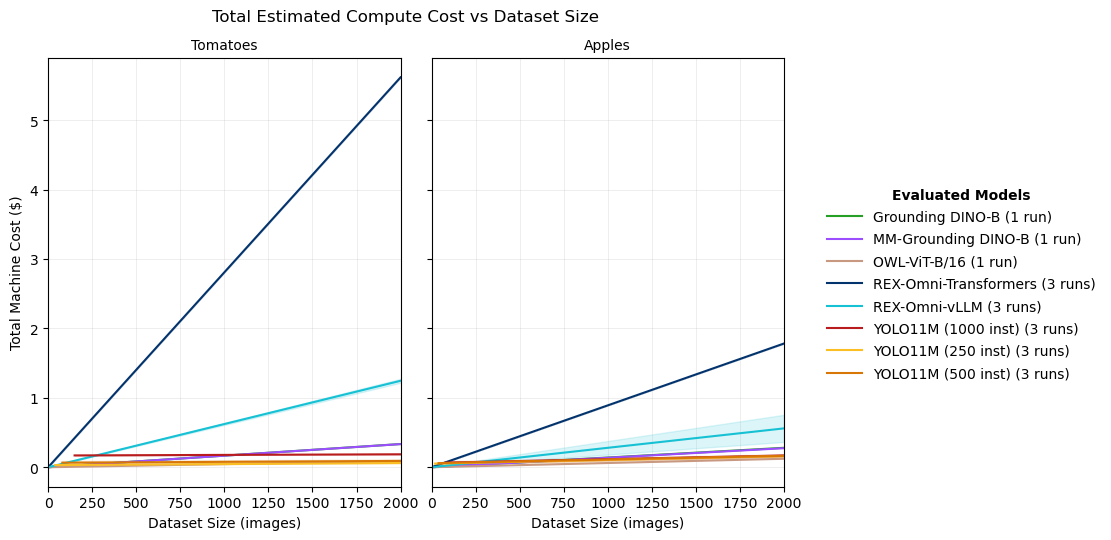

(<Figure size 800x500 with 2 Axes>,
 array([<Axes: title={'center': 'Tomatoes'}, xlabel='Dataset Size (images)', ylabel='Total Machine Cost ($)'>,
        <Axes: title={'center': 'Apples'}, xlabel='Dataset Size (images)'>],
       dtype=object))

In [27]:
plot_total_compute_cost(DATASETS=DATASETS, experiment="Experiment_1")

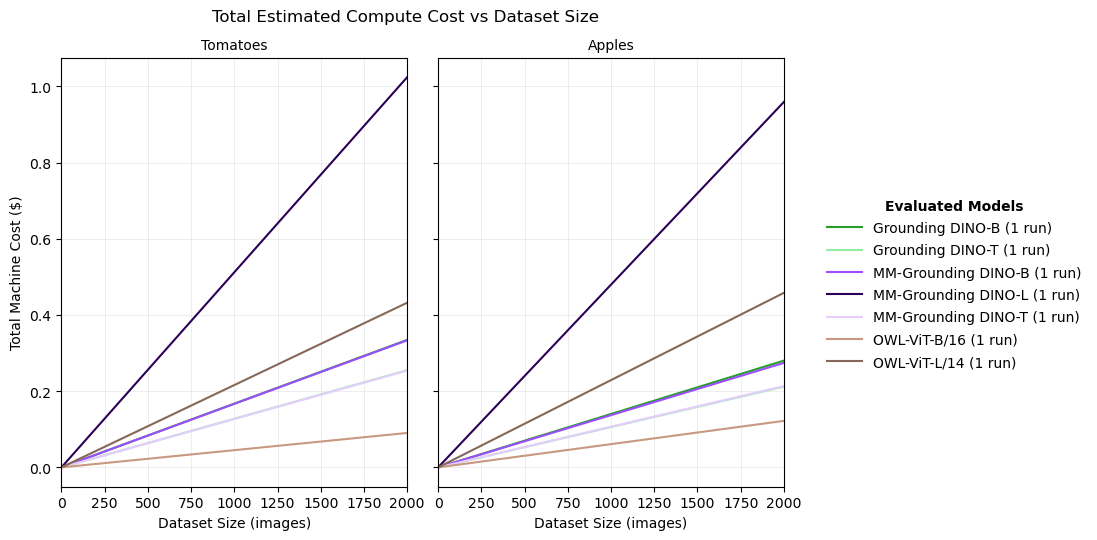

(<Figure size 800x500 with 2 Axes>,
 array([<Axes: title={'center': 'Tomatoes'}, xlabel='Dataset Size (images)', ylabel='Total Machine Cost ($)'>,
        <Axes: title={'center': 'Apples'}, xlabel='Dataset Size (images)'>],
       dtype=object))

In [28]:
plot_total_compute_cost(DATASETS=DATASETS, experiment="Experiment_2.1")

In [53]:
eval_info

{'num_initial_bbox': 0,
 't_add': 5.452281021897811,
 't_remove': 2.0005069124423964,
 't_review': 0.3333333333333333,
 't_train': 0.0,
 'image_t_inf': 0.2483762926497166,
 'image_num_pred': 0.25806451612903225,
 'precision': 0.75,
 'recall': 0.014563106796116505,
 'dataset': 'apples',
 'model_name': 'gd_b'}

In [ ]:
# # Time & Cost calculations
# machine_training_time_s = preds.get("info", {}).get("machine_training_time_s", 0.0)
# total_inference_time_s = preds.get("info", {}).get("total_inference_time_s", 0.0)

# # Machine time
# total_machine_time = machine_training_time_s + total_inference_time_s

# # Manual time
# num_initial_bbox = preds.get("info", {}).get("num_initial_bbox", 0)
# add_time = ANNOTATION_TIMES.get(dataset_name, {}).get("add", DEFAULT_ADD_TIME)
# remove_time = ANNOTATION_TIMES.get(dataset_name, {}).get("remove", DEFAULT_REMOVE_TIME)
# review_time = REVIEW_TIME_PER_BOX

# total_manual_time = (
#     num_initial_bbox * add_time
#     + num_predicted_bbox * review_time
#     + bbox_removals * remove_time
#     + bbox_additions * add_time
# )

# # Cost
# total_compute_cost = (total_machine_time / 3600) * HOURLY_COMPUTE_COST

# # Total annotation time
# total_annotation_time = total_machine_time + total_manual_time

# # Per-bbox statistics
# annotation_time_per_bbox = (
#     total_annotation_time / num_gt_bbox if num_gt_bbox > 0 else 0.0
# )
# annotation_cost_per_bbox = (
#     total_compute_cost / num_gt_bbox if num_gt_bbox > 0 else 0.0
# )

# # Percentages
# manual_time_pct = (
#     (total_manual_time / total_annotation_time) * 100.0
#     if total_annotation_time > 0 else 0.0
# )
# machine_time_pct = 100.0 - manual_time_pct

# eff_metrics["total_annotation_time_s"] = total_annotation_time
# eff_metrics["annotation_time_per_bbox_s"] = annotation_time_per_bbox
# eff_metrics["annotation_time_manual_pct"] = manual_time_pct
# eff_metrics["annotation_time_machine_pct"] = machine_time_pct
# eff_metrics["total_cost_usd"] = total_compute_cost
# eff_metrics["cost_per_bbox_usd"] = annotation_cost_per_bbox